# CBC Diagnosis — Full ML Pipeline (Clean)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

## 1. Load Data

In [2]:
df = pd.read_csv('diagnosed_cbc_data_v4.csv')
df.head()

,WBC,LYMp,NEUTp,LYMn,NEUTn,RBC,HGB,HCT,MCV,MCH,MCHC,PLT,PDW,PCT,Diagnosis
0,10.0,43.2,50.1,4.3,5.0,2.77,7.3,24.2,87.7,26.3,30.1,189.0,12.5,0.17,Normocytic hypochromic anemia
1,10.0,42.4,52.3,4.2,5.3,2.84,7.3,25.0,88.2,25.7,20.2,180.0,12.5,0.16,Normocytic hypochromic anemia
2,7.2,30.7,60.7,2.2,4.4,3.97,9.0,30.5,77.0,22.6,29.5,148.0,14.3,0.14,Iron deficiency anemia
3,6.0,30.2,63.5,1.8,3.8,4.22,3.8,32.8,77.9,23.2,29.8,143.0,11.3,0.12,Iron deficiency anemia
4,4.2,39.1,53.7,1.6,2.3,3.93,0.4,316.0,80.6,23.9,29.7,236.0,12.8,0.22,Normocytic hypochromic anemia


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1281 entries, 0 to 1280
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   WBC        1281 non-null   float64
 1   LYMp       1281 non-null   float64
 2   NEUTp      1281 non-null   float64
 3   LYMn       1281 non-null   float64
 4   NEUTn      1281 non-null   float64
 5   RBC        1281 non-null   float64
 6   HGB        1281 non-null   float64
 7   HCT        1281 non-null   float64
 8   MCV        1281 non-null   float64
 9   MCH        1281 non-null   float64
 10  MCHC       1281 non-null   float64
 11  PLT        1281 non-null   float64
 12  PDW        1281 non-null   float64
 13  PCT        1281 non-null   float64
 14  Diagnosis  1281 non-null   object 
dtypes: float64(14), object(1)
memory usage: 150.2+ KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
WBC,1281.0,7.862717,3.564466,0.80,6.00000,7.400000,8.68000,45.7
LYMp,1281.0,25.845000,7.038728,6.20,25.84500,25.845000,25.84500,91.4
NEUTp,1281.0,77.511000,147.746273,0.70,71.10000,77.511000,77.51100,5317.0
LYMn,1281.0,1.880760,1.335689,0.20,1.88076,1.880760,1.88076,41.8
NEUTn,1281.0,5.140940,2.872294,0.50,5.10000,5.140940,5.14094,79.0
RBC,1281.0,4.708267,2.817200,1.36,4.19000,4.600000,5.10000,90.8
HGB,1281.0,12.184551,3.812897,-10.00,10.80000,12.300000,13.50000,87.1
HCT,1281.0,46.152600,104.886100,2.00,39.20000,46.152600,46.15260,3715.0
MCV,1281.0,85.793919,27.177663,-79.30,81.20000,86.600000,90.20000,990.0
MCH,1281.0,32.084840,111.170756,10.90,25.50000,27.800000,29.60000,3117.0


## 2. EDA

In [6]:
print('Shape:', df.shape)
print('Missing values:', df.isnull().sum().sum())
print('Duplicates:', df.duplicated().sum())
df.drop_duplicates(inplace=True)
print('After dedup shape:', df.shape)
print()
print(df['Diagnosis'].value_counts())

Shape: (1281, 15)
Missing values: 0
Duplicates: 49
After dedup shape: (1232, 15)

Diagnosis
Healthy                           323
Normocytic hypochromic anemia     271
Normocytic normochromic anemia    255
Iron deficiency anemia            184
Thrombocytopenia                   72
Other microcytic anemia            56
Leukemia                           44
Macrocytic anemia                  16
Leukemia with thrombocytopenia     11
Name: count, dtype: int64


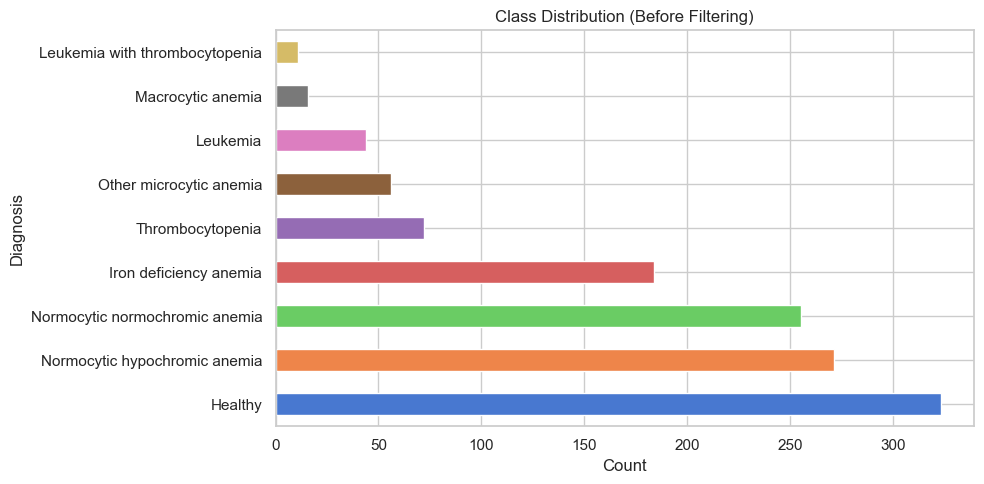

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
counts = df['Diagnosis'].value_counts()
counts.plot(kind='barh', ax=ax, color=sns.color_palette('muted', len(counts)))
ax.set_title('Class Distribution (Before Filtering)')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

## 3. Drop Low-Count Classes

Classes with fewer than 20 samples offer no meaningful signal and hurt model generalization:
- **Leukemia with thrombocytopenia** (~10 samples)
- **Macrocytic anemia** (~15 samples)

Remaining minority classes will be handled via SMOTE after splitting.

In [8]:
DROP_CLASSES = ['Leukemia with thrombocytopenia', 'Macrocytic anemia']
df = df[~df['Diagnosis'].isin(DROP_CLASSES)].reset_index(drop=True)
print('Remaining classes:')
print(df['Diagnosis'].value_counts())

Remaining classes:
Diagnosis
Healthy                           323
Normocytic hypochromic anemia     271
Normocytic normochromic anemia    255
Iron deficiency anemia            184
Thrombocytopenia                   72
Other microcytic anemia            56
Leukemia                           44
Name: count, dtype: int64


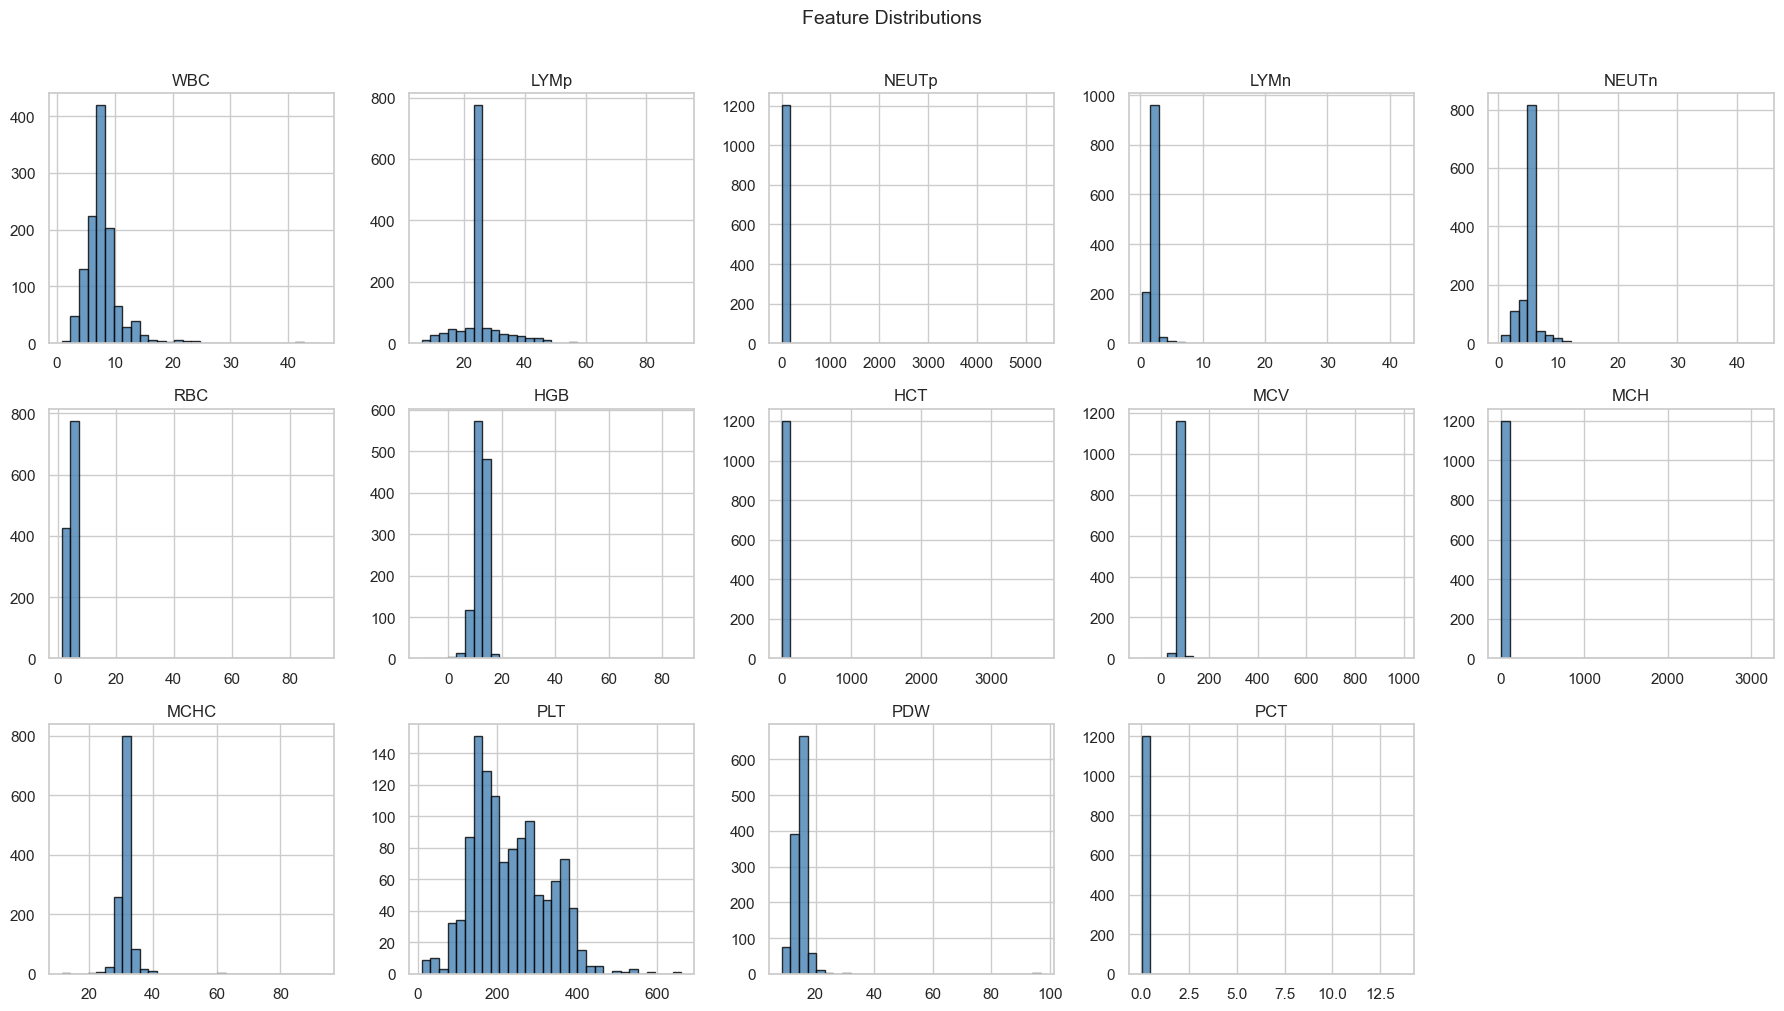

In [9]:
features = df.columns.drop('Diagnosis').tolist()

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
for ax, col in zip(axes.flatten(), features):
    df[col].hist(ax=ax, bins=30, edgecolor='black', color='steelblue', alpha=0.8)
    ax.set_title(col)
for ax in axes.flatten()[len(features):]:
    ax.set_visible(False)
plt.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

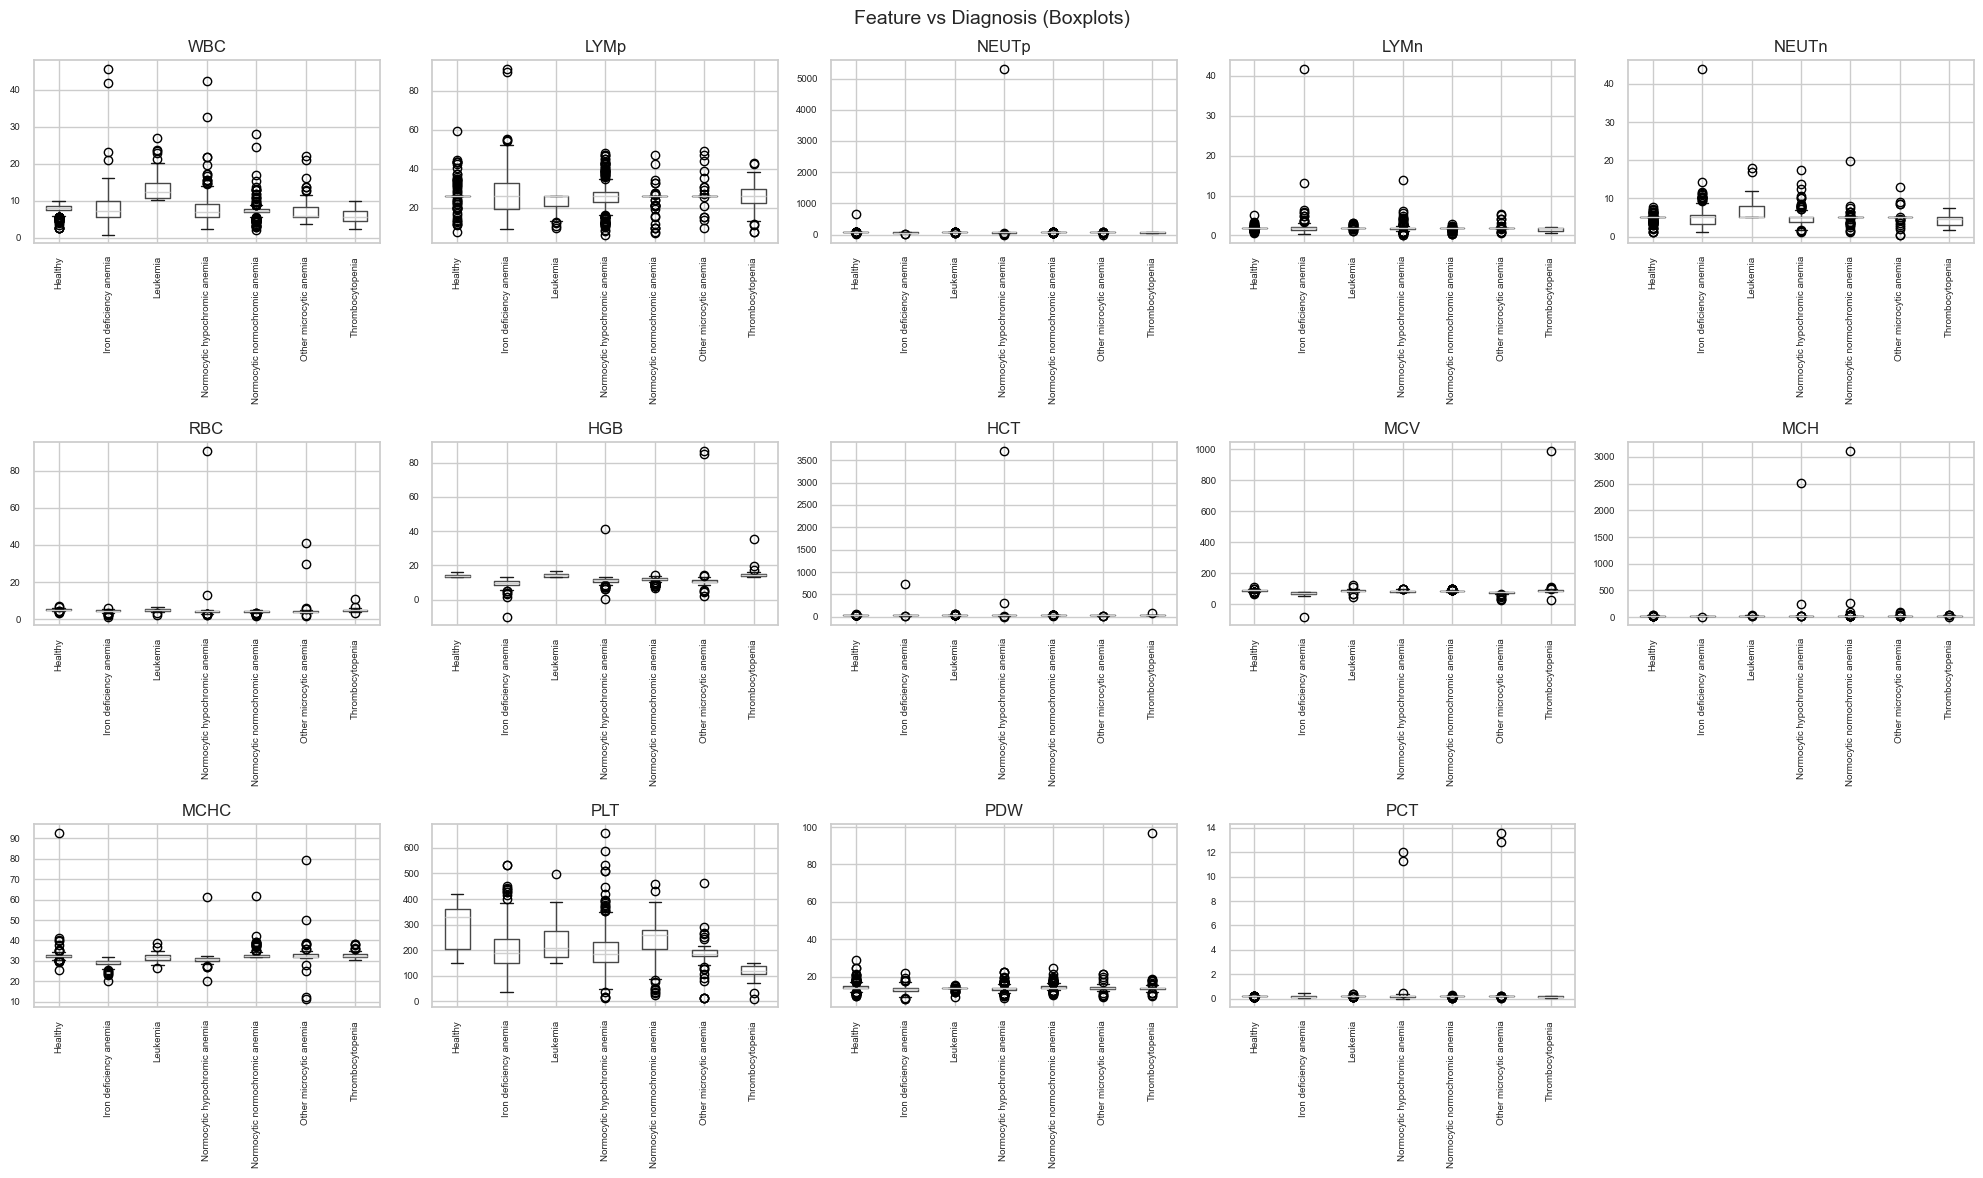

In [10]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
for ax, col in zip(axes.flatten(), features):
    df.boxplot(column=col, by='Diagnosis', ax=ax, rot=90, fontsize=7)
    ax.set_title(col)
    ax.set_xlabel('')
for ax in axes.flatten()[len(features):]:
    ax.set_visible(False)
plt.suptitle('Feature vs Diagnosis (Boxplots)', fontsize=14)
plt.tight_layout()
plt.show()

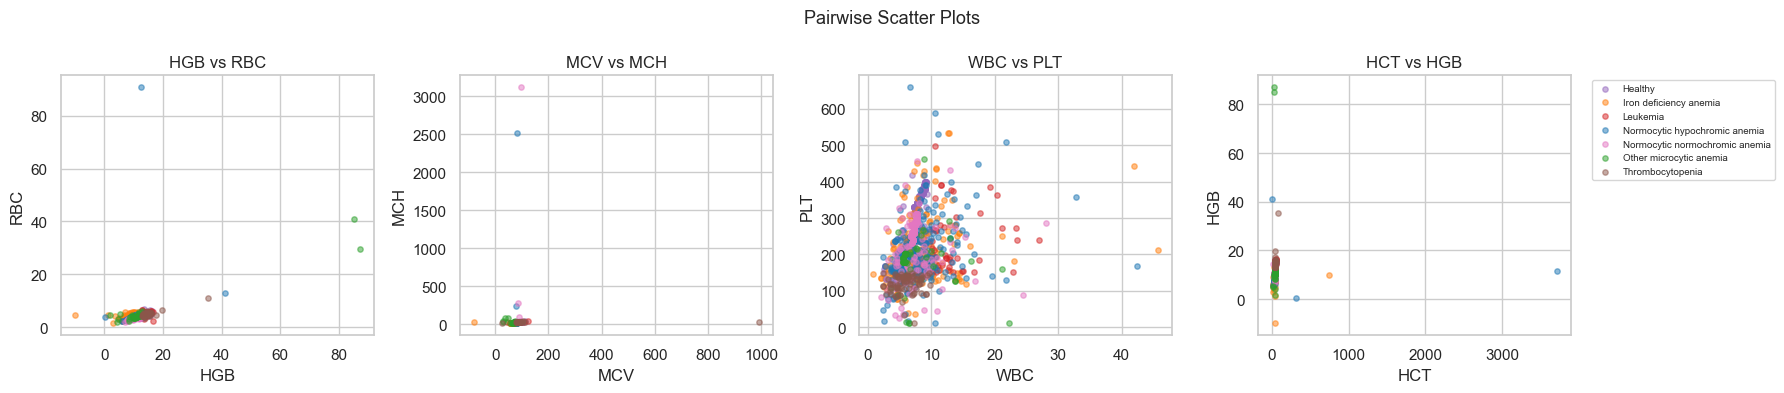

In [11]:
key_pairs = [('HGB', 'RBC'), ('MCV', 'MCH'), ('WBC', 'PLT'), ('HCT', 'HGB')]
palette   = sns.color_palette('tab10', df['Diagnosis'].nunique())
color_map = dict(zip(df['Diagnosis'].unique(), palette))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (x, y) in zip(axes, key_pairs):
    for label, grp in df.groupby('Diagnosis'):
        ax.scatter(grp[x], grp[y], label=label, alpha=0.5, s=15, color=color_map[label])
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}')
axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.suptitle('Pairwise Scatter Plots', fontsize=13)
plt.tight_layout()
plt.show()

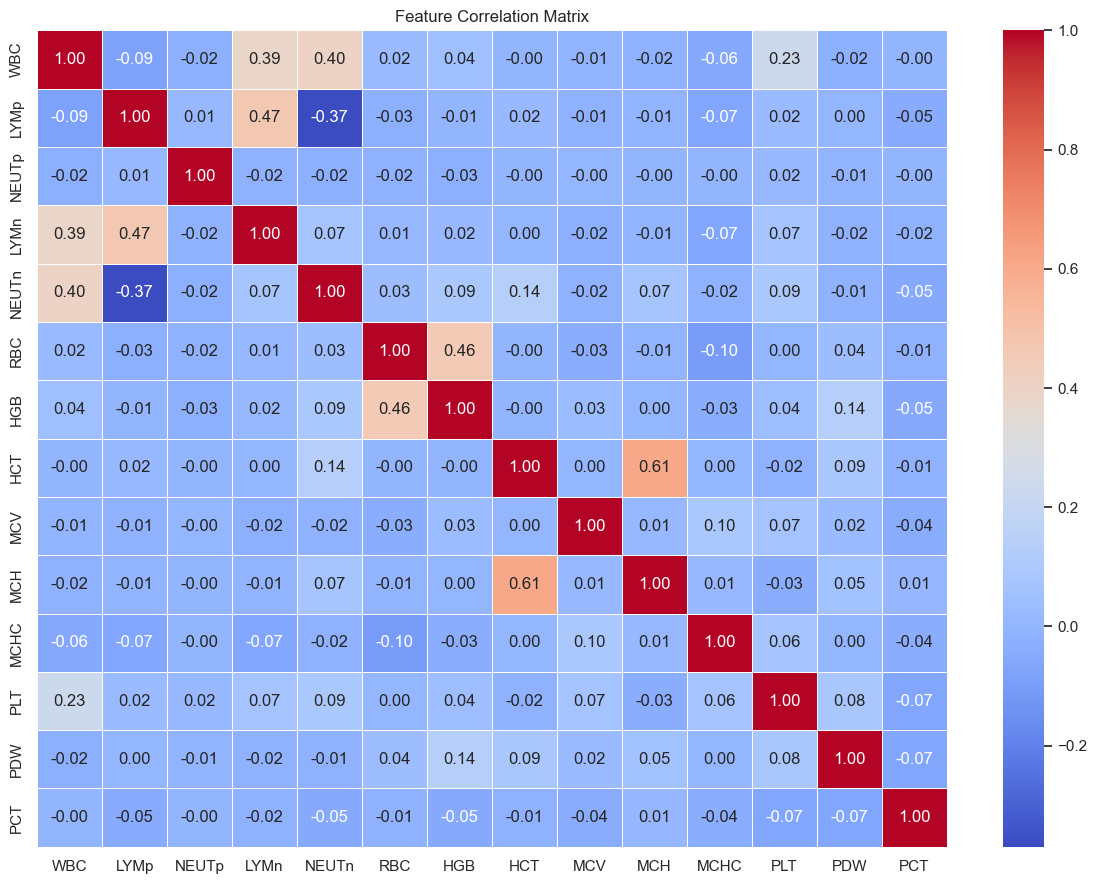

In [12]:
corr = df[features].corr()
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.4)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [13]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

X = df[features].copy()
y = df['Diagnosis'].copy()

le = LabelEncoder()
y_enc = le.fit_transform(y)
print('Classes:', list(le.classes_))

Classes: ['Healthy', 'Iron deficiency anemia', 'Leukemia', 'Normocytic hypochromic anemia', 'Normocytic normochromic anemia', 'Other microcytic anemia', 'Thrombocytopenia']


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (964, 14) | Test: (241, 14)


In [53]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=features)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=features)

In [54]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE on train only
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print('Before SMOTE:', pd.Series(y_train).value_counts().to_dict())
print('After  SMOTE:', pd.Series(y_train_res).value_counts().to_dict())

Before SMOTE: {0: 258, 3: 217, 4: 204, 1: 147, 6: 58, 5: 45, 2: 35}
After  SMOTE: {1: 258, 3: 258, 5: 258, 4: 258, 2: 258, 0: 258, 6: 258}


# With SMOTE

## 5. Feature Selection

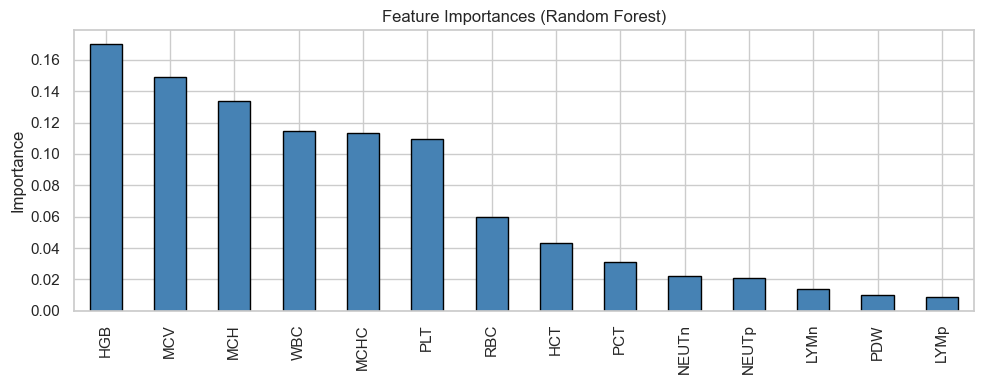

Top 8 Features: ['HGB', 'MCV', 'MCH', 'WBC', 'MCHC', 'PLT', 'RBC', 'HCT']


In [55]:
from sklearn.ensemble import RandomForestClassifier

rf_sel = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_sel.fit(X_train_res, y_train_res)

importances = pd.Series(rf_sel.feature_importances_, index=features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
importances.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Feature Importances (Random Forest)')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.show()

selected_features = importances.index[:8].tolist()
print('Top 8 Features:', selected_features)

In [56]:
X_train_sel = X_train_res[selected_features]
X_test_sel  = X_test_scaled[selected_features]

## 6. Train Multiple Models

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import cross_val_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Extra Trees':         ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'SVM':                 SVC(probability=True, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
}

In [58]:
results = {}
for name, model in models.items():
    model.fit(X_train_sel, y_train_res)
    y_pred = model.predict(X_test_sel)
    results[name] = {
        'Accuracy':    accuracy_score(y_test, y_pred),
        'F1':          f1_score(y_test, y_pred, average='weighted'),
        'CV Accuracy': cross_val_score(model, X_train_sel, y_train_res, cv=5, scoring='accuracy').mean()
    }

results_df = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)
results_df

,Accuracy,F1,CV Accuracy
Gradient Boosting,0.991701,0.991746,0.992256
Random Forest,0.987552,0.987639,0.996125
Decision Tree,0.987552,0.988187,0.995569
Extra Trees,0.912863,0.912393,0.962902
SVM,0.817427,0.824427,0.893142
KNN,0.788382,0.792868,0.890931
Logistic Regression,0.721992,0.741037,0.815101


## 7. Visualize Results

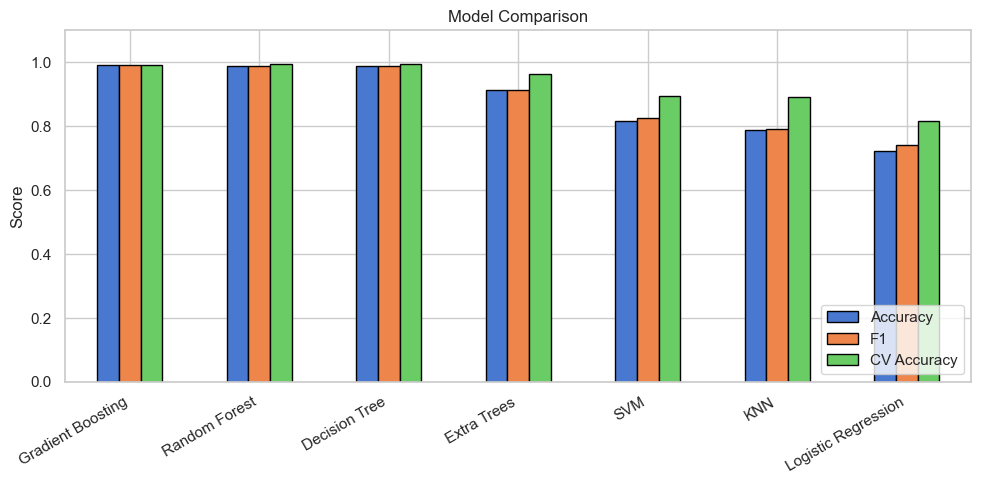

In [59]:
fig, ax = plt.subplots(figsize=(10, 5))
results_df[['Accuracy', 'F1', 'CV Accuracy']].plot(kind='bar', ax=ax, edgecolor='black')
ax.set_title('Model Comparison')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

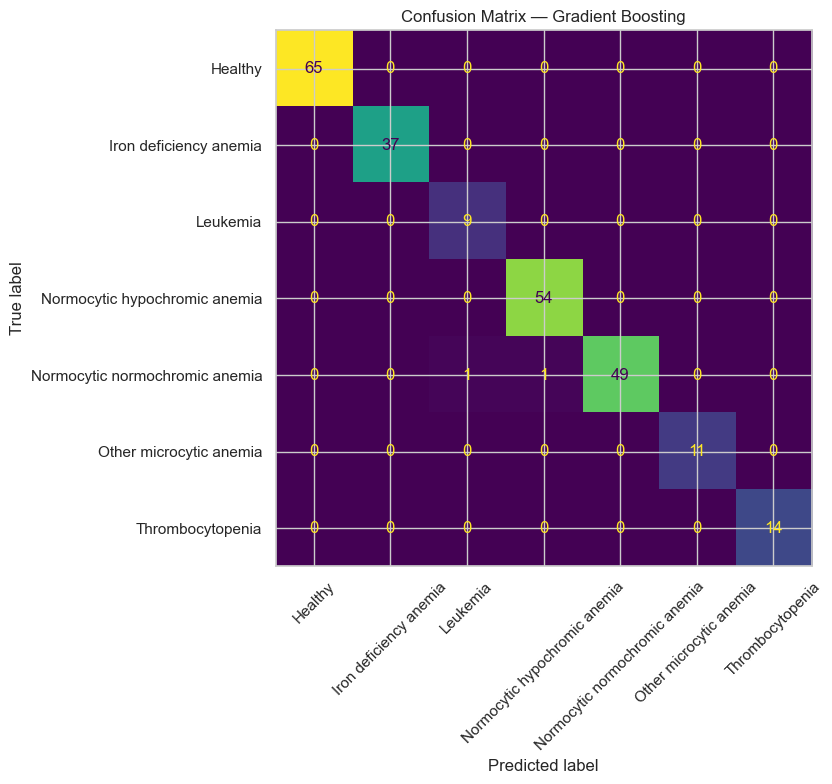

In [60]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_single_name  = results_df.index[0]
best_single_model = models[best_single_name]
y_pred_best       = best_single_model.predict(X_test_sel)

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_best), display_labels=le.classes_).plot(
    ax=ax, colorbar=False, xticks_rotation=45
)
ax.set_title(f'Confusion Matrix — {best_single_name}')
plt.tight_layout()
plt.show()

In [61]:
print(f'Classification Report — {best_single_name}\n')
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

Classification Report — Gradient Boosting

                                precision    recall  f1-score   support

                       Healthy       1.00      1.00      1.00        65
        Iron deficiency anemia       1.00      1.00      1.00        37
                      Leukemia       0.90      1.00      0.95         9
 Normocytic hypochromic anemia       0.98      1.00      0.99        54
Normocytic normochromic anemia       1.00      0.96      0.98        51
       Other microcytic anemia       1.00      1.00      1.00        11
              Thrombocytopenia       1.00      1.00      1.00        14

                      accuracy                           0.99       241
                     macro avg       0.98      0.99      0.99       241
                  weighted avg       0.99      0.99      0.99       241



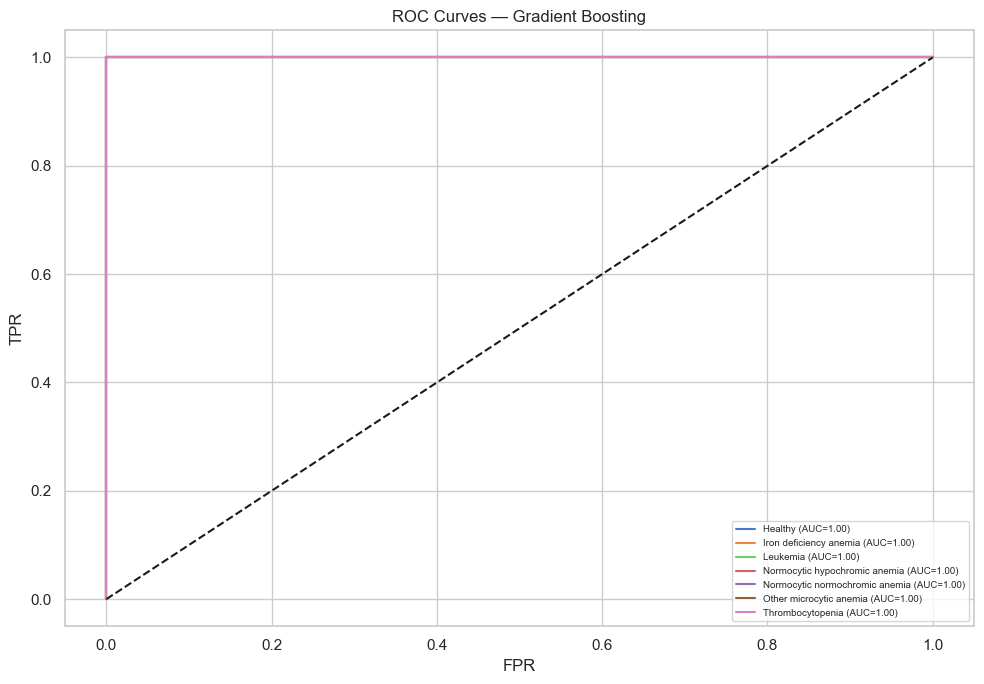

In [62]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

n_classes  = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=range(n_classes))
y_prob     = best_single_model.predict_proba(X_test_sel)

fig, ax = plt.subplots(figsize=(10, 7))
for i, cls in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    ax.plot(fpr, tpr, label=f'{cls} (AUC={auc(fpr, tpr):.2f})')
ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title(f'ROC Curves — {best_single_name}')
ax.legend(fontsize=7, loc='lower right')
plt.tight_layout()
plt.show()

## 8. Ensemble Models

In [63]:
from sklearn.ensemble import VotingClassifier, StackingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ('rf',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
        ('gb',  GradientBoostingClassifier(n_estimators=100, random_state=42)),
        ('et',  ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
        ('svm', SVC(probability=True, random_state=42)),
        ('knn', KNeighborsClassifier(n_neighbors=5)),
    ],
    voting='soft'
)
voting_clf.fit(X_train_sel, y_train_res)

VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(n_jobs=-1,
                                                     random_state=42)),
                             ('gb',
                              GradientBoostingClassifier(random_state=42)),
                             ('et',
                              ExtraTreesClassifier(n_jobs=-1, random_state=42)),
                             ('svm', SVC(probability=True, random_state=42)),
                             ('knn', KNeighborsClassifier())],
                 voting='soft')

In [64]:
stacking_clf = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
        ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
        ('et', ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)
stacking_clf.fit(X_train_sel, y_train_res)

StackingClassifier(cv=5,
                   estimators=[('rf',
                                RandomForestClassifier(n_jobs=-1,
                                                       random_state=42)),
                               ('gb',
                                GradientBoostingClassifier(random_state=42)),
                               ('et',
                                ExtraTreesClassifier(n_jobs=-1,
                                                     random_state=42))],
                   final_estimator=LogisticRegression(max_iter=1000))

In [65]:
ensemble_results = {}
for name, model in [('Voting Ensemble', voting_clf), ('Stacking Ensemble', stacking_clf)]:
    y_pred = model.predict(X_test_sel)
    ensemble_results[name] = {
        'Accuracy':    accuracy_score(y_test, y_pred),
        'F1':          f1_score(y_test, y_pred, average='weighted'),
        'CV Accuracy': cross_val_score(model, X_train_sel, y_train_res, cv=5, scoring='accuracy').mean()
    }

ensemble_df = pd.DataFrame(ensemble_results).T
ensemble_df

,Accuracy,F1,CV Accuracy
Voting Ensemble,0.975104,0.975667,0.993910
Stacking Ensemble,0.991701,0.991746,0.996125


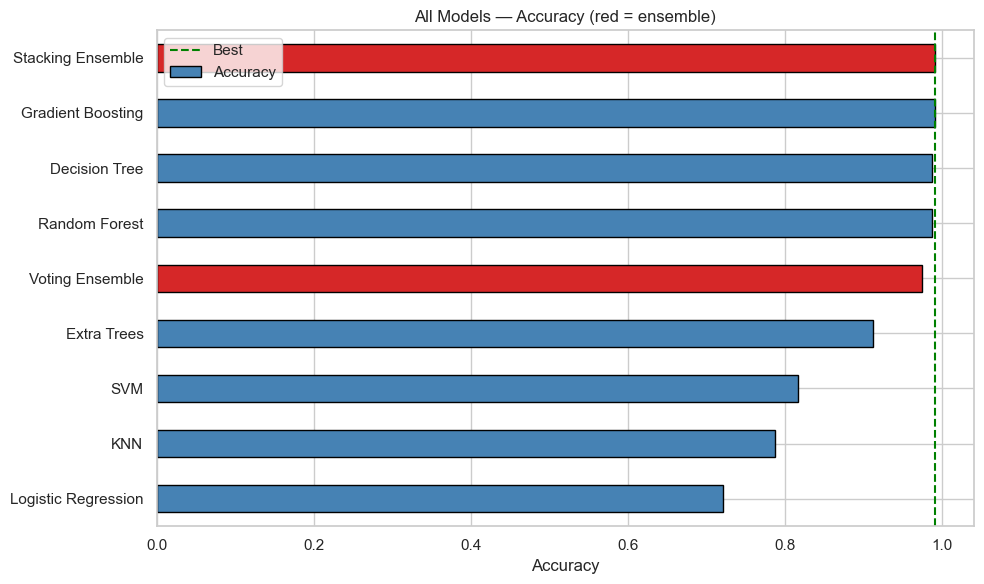

In [66]:
all_results_df = pd.concat([results_df, ensemble_df]).sort_values('Accuracy', ascending=True)

colors = ['#d62728' if 'Ensemble' in i else 'steelblue' for i in all_results_df.index]
fig, ax = plt.subplots(figsize=(10, 6))
all_results_df['Accuracy'].plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_title('All Models — Accuracy (red = ensemble)')
ax.set_xlabel('Accuracy')
ax.axvline(all_results_df['Accuracy'].max(), color='green', linestyle='--', label='Best')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Best Model — Final Evaluation

In [44]:
all_models   = {**models, 'Voting Ensemble': voting_clf, 'Stacking Ensemble': stacking_clf}
all_combined = pd.concat([results_df, ensemble_df])
best_name    = all_combined['Accuracy'].idxmax()
best_final   = all_models[best_name]
print('Best model:', best_name, '| Accuracy:', round(all_combined.loc[best_name, 'Accuracy'], 4))

Best model: Gradient Boosting | Accuracy: 0.9917


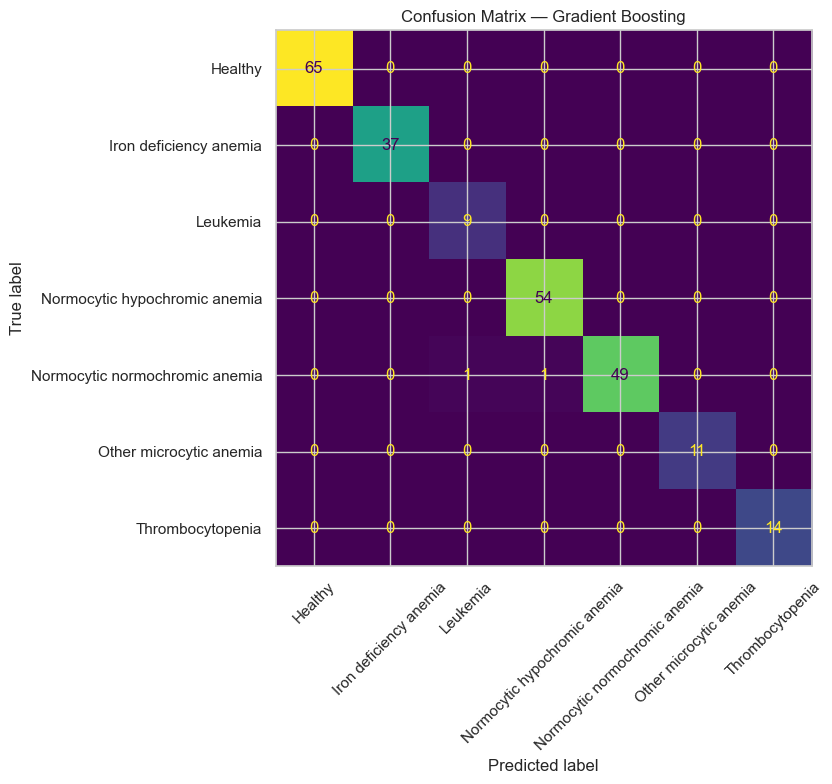

In [45]:
y_pred_final = best_final.predict(X_test_sel)

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_final), display_labels=le.classes_).plot(
    ax=ax, colorbar=False, xticks_rotation=45
)
ax.set_title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()

In [46]:
print(classification_report(y_test, y_pred_final, target_names=le.classes_))

                                precision    recall  f1-score   support

                       Healthy       1.00      1.00      1.00        65
        Iron deficiency anemia       1.00      1.00      1.00        37
                      Leukemia       0.90      1.00      0.95         9
 Normocytic hypochromic anemia       0.98      1.00      0.99        54
Normocytic normochromic anemia       1.00      0.96      0.98        51
       Other microcytic anemia       1.00      1.00      1.00        11
              Thrombocytopenia       1.00      1.00      1.00        14

                      accuracy                           0.99       241
                     macro avg       0.98      0.99      0.99       241
                  weighted avg       0.99      0.99      0.99       241



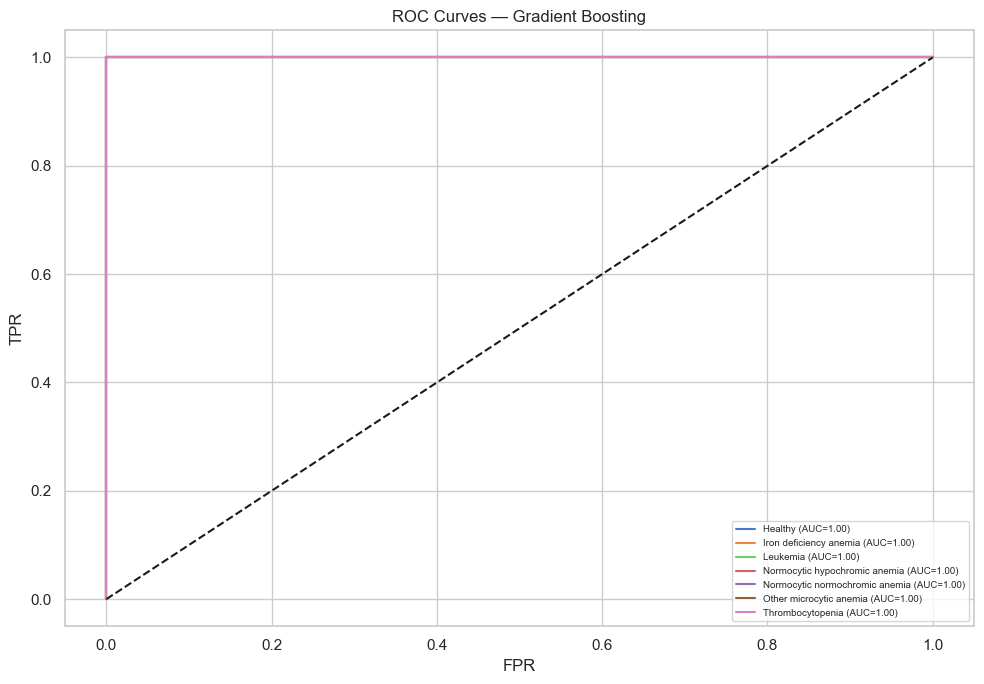

In [47]:
y_prob_final = best_final.predict_proba(X_test_sel)
y_test_bin   = label_binarize(y_test, classes=range(n_classes))

fig, ax = plt.subplots(figsize=(10, 7))
for i, cls in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_final[:, i])
    ax.plot(fpr, tpr, label=f'{cls} (AUC={auc(fpr, tpr):.2f})')
ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title(f'ROC Curves — {best_name}')
ax.legend(fontsize=7, loc='lower right')
plt.tight_layout()
plt.show()

## 10. Save Models

In [48]:
#best_final= voting_clf
joblib.dump(best_final,        'best_model.pkl')
joblib.dump(scaler,            'scaler.pkl')
joblib.dump(le,                'label_encoder.pkl')
joblib.dump(selected_features, 'selected_features.pkl')
print('Saved: best_model.pkl | scaler.pkl | label_encoder.pkl | selected_features.pkl')

Saved: best_model.pkl | scaler.pkl | label_encoder.pkl | selected_features.pkl


## 11. Inference Example

In [49]:
loaded_model    = joblib.load('best_model.pkl')
loaded_scaler   = joblib.load('scaler.pkl')
loaded_le       = joblib.load('label_encoder.pkl')
loaded_features = joblib.load('selected_features.pkl')

all_features = loaded_scaler.feature_names_in_.tolist()

manual_values = {
    'HGB': 13.5, 'MCHC': 33, 'MCV': 85, 'MCH': 28,
    'RBC': 4.7,  'PLT': 250, 'WBC': 7,  'HCT': 40
}

# Build a row with all features (fill missing with 0)
sample_dict = {f: 0.0 for f in all_features}
sample_dict.update(manual_values)

sample         = pd.DataFrame([sample_dict])[all_features]
sample_scaled  = pd.DataFrame(loaded_scaler.transform(sample), columns=all_features)
sample_sel     = sample_scaled[loaded_features]  # select by name — no selector object needed

pred = loaded_model.predict(sample_sel)
prob = loaded_model.predict_proba(sample_sel)

print('Predicted :', loaded_le.inverse_transform(pred)[0])
print('Confidence:', f'{prob.max():.2%}')

Predicted : Healthy
Confidence: 100.00%


# Without SMOTE

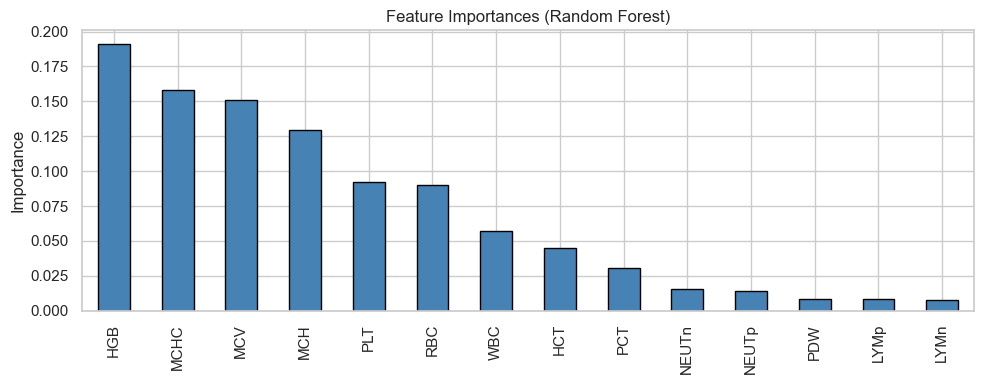

Top 8 Features: ['HGB', 'MCHC', 'MCV', 'MCH', 'PLT', 'RBC', 'WBC', 'HCT']


In [50]:
from sklearn.ensemble import RandomForestClassifier

rf_sel = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_sel.fit(X_train, y_train)

importances = pd.Series(rf_sel.feature_importances_, index=features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
importances.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Feature Importances (Random Forest)')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.show()

selected_features = importances.index[:8].tolist()
print('Top 8 Features:', selected_features)

In [67]:
X_train_sel = X_train[selected_features]
X_test_sel  = X_test_scaled[selected_features]

## 6. Train Multiple Models

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import cross_val_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Extra Trees':         ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'SVM':                 SVC(probability=True, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
}

In [74]:
results = {}
for name, model in models.items():
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    results[name] = {
        'Accuracy':    accuracy_score(y_test, y_pred),
        'F1':          f1_score(y_test, y_pred, average='weighted'),
        'CV Accuracy': cross_val_score(model, X_train_sel, y_train, cv=5, scoring='accuracy').mean()
    }

results_df = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)
results_df

,Accuracy,F1,CV Accuracy
Logistic Regression,0.174274,0.152951,0.727234
Decision Tree,0.153527,0.040867,0.989621
Random Forest,0.153527,0.040867,0.990663
Gradient Boosting,0.153527,0.040867,0.988590
SVM,0.153527,0.040867,0.491677
KNN,0.153527,0.040867,0.697085
Extra Trees,0.045643,0.003985,0.908700
